# 01｜亲手读懂 VC2026 的真实数据

从 `data/vcc2026-validation/` 出发，把一个 `.h5ad` 文件变成你能解释的生物量和模型输入。

**学习目标：** 认清文件、细胞、基因、靶点、NTC guide；读懂 `.X/.obs/.var`；分块审计三个背景；理解 raw counts 与 log1p 的区别。

**运行方式：** 先按 [notebook/README.md](README.md) 安装学习依赖并选仓库 `.venv` kernel，然后从上到下运行。默认 CPU，不下载数据，不训练 State。完整 QC 会扫描 55,200 个细胞，耗时取决于磁盘解压速度；不会把整份表达矩阵转成 dense。图中英文标签便于跨系统显示，解释使用中文。

本课数字分为三类：官方合同、运行时从本地文件测得的值、单独标识的数学示例。没有目标扰动真值，就不计算预测成绩。

In [1]:
from pathlib import Path
import sys, json, hashlib, time
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse
from IPython.display import display, Markdown

# 从仓库根目录或 notebook/ 启动都可以；不写死某台机器的绝对路径。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'pyproject.toml').exists()
             and (p / 'docs/Official-website').is_dir()), None)
if ROOT is None:
    raise RuntimeError('请在 virtual-cell-2026 仓库内启动 notebook')
DATA = ROOT / 'data/vcc2026-validation/controls'
if not (DATA / 'manifest.json').exists():
    raise FileNotFoundError(f'缺少 {DATA}；请先放好官方 controls 数据包')
OUT = ROOT / 'output/notebook-learning/01-data'
OUT.mkdir(parents=True, exist_ok=True)
manifest = json.loads((DATA / 'manifest.json').read_text())
genes = pd.read_csv(DATA / 'gene_names.csv')['gene_name'].astype(str).tolist()
targets = pd.read_csv(DATA / 'pert_counts.csv')['target_gene'].astype(str).tolist()
contexts = manifest['contexts']
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'],
    'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False, 'figure.dpi': 110,
    'svg.fonttype': 'none', 'pdf.fonttype': 42,
})
COLORS = {'A': '#167B72', 'B': '#3E71AD', 'C': '#DC654F'}
pd.set_option('display.max_rows', 12)
pd.set_option('display.max_columns', 12)
def show_figure(fig, name):
    # 完整可再生成图只写入 Git 忽略目录；notebook 内嵌适合阅读的预览。
    fig.savefig(OUT / f'{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUT / f'{name}.svg', bbox_inches='tight')
    fig.savefig(OUT / f'{name}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
print('Python:', sys.version.split()[0], '| 数据目录:', DATA.relative_to(ROOT))
print('本课输出目录:', OUT.relative_to(ROOT))

Python: 3.13.14 | 数据目录: data/vcc2026-validation/controls
本课输出目录: output/notebook-learning/01-data


## 单元一：这些文件来自什么实验

**基因表达（gene expression）** 在这里指 RNA 的检测计数。实验用 **CRISPRi（CRISPR interference，CRISPR 干扰）** 压低基因表达，它的机器由两部分组成：**失活的 Cas 蛋白**（dCas9，仍能结合 DNA，但不再切割）和**向导 RNA（guide RNA，sgRNA）**——guide 中约 20 个碱基的序列决定整台机器结合到基因组的哪个位置，通常是目标基因的转录起始位点；随行的 **KRAB** 抑制结构域到位后压低该基因的转录，下游基因可能随之改变。guide 只负责导航、不敲坏基因，好比一辆只听导航的车：CRISPRi 是把目标基因“关小音量”，而不是把表达矩阵一列强制设成零。

**NTC（non-targeting control，非靶向对照）** 细胞同样被递送 guide、表达整套 CRISPRi 机器、走完全部实验流程，只是 guide 序列被设计成不匹配人类基因组任何位置——车照常出车，导航里却输了一个不存在的地址，没有任何基因被定向抑制。所以 NTC 是**流程对照**而非“无扰动”：它承受递送与蛋白表达的负担，用来把“CRISPRi 流程本身的影响”和“敲低某个基因的效果”分开。对照也不只一条 guide：46 条序列各异的 NTC guide 让“对照”代表一组 guide 的平均行为，而不是某一条序列的怪癖。**Perturb-seq** 测序时把每个细胞实际携带的 guide 一并读出，扰动标签才与单细胞 RNA 测量连接。比赛的 A/B/C 是匿名**细胞背景（cell context）**，编号并不告诉我们细胞身份。

10x Flex 的简化信息链：固定细胞中的 RNA 与成对探针结合 → 相邻探针连接 → 连接产物获得细胞条形码和分子标记 → 扩增、测序 → 按细胞/基因归属并用 **UMI（unique molecular identifier，唯一分子标识）** 去除扩增重复。输出是去重后的检测量，受捕获、探针效率与细胞状态影响，不是全部 RNA 的无损清点。详细机制见 [基础课](../docs/lessons/01-数据合同与首个基线.md)。

我们拿到的是 **A/B/C 的 NTC 输入**；300 个目标的扰动后表达没有公开。文件夹名里的 `validation` 表示用于服务器验证轮，不能理解成“本地有验证标签”。

In [2]:
roles = {
    'context_A.h5ad': 'A 的对照细胞表达',
    'context_B.h5ad': 'B 的对照细胞表达',
    'context_C.h5ad': 'C 的对照细胞表达',
    'gene_names.csv': '最终输出必须使用的基因顺序',
    'pert_counts.csv': '要预测的靶点名单，不是表达标签',
    'manifest.json': '赛季、背景、形状等合同信息',
}
display(pd.DataFrame([{'file': p.name, 'MB': round(p.stat().st_size / 1e6, 3),
                       'role': roles.get(p.name, '其他文件')}
                      for p in sorted(DATA.iterdir()) if p.is_file()]))
display(pd.Series({k: manifest[k] for k in ['season', 'partition', 'panel_id',
                                           'n_genes', 'n_constructs', 'cells_per_pert']}))
display(pd.DataFrame({'gene_names 前5行': genes[:5], 'target_gene 前5行': targets[:5]}))

,file,MB,role
0,context_A.h5ad,224.973,A 的对照细胞表达
1,context_B.h5ad,210.966,B 的对照细胞表达
2,context_C.h5ad,226.057,C 的对照细胞表达
3,gene_names.csv,0.119,最终输出必须使用的基因顺序
4,manifest.json,0.001,赛季、背景、形状等合同信息
5,pert_counts.csv,0.002,要预测的靶点名单，不是表达标签


season                     2026
partition                   val
panel_id          vcc2026-val-1
n_genes                   18533
n_constructs                300
cells_per_pert              400
dtype: object

,gene_names 前5行,target_gene 前5行
0,TSPAN6,ABCD1
1,TNMD,ACLY
2,DPM1,ADNP
3,SCYL3,AGO1
4,C1orf112,AKAP1


`gene_names.csv` 是**输出维度**，`pert_counts.csv` 是**输入条件**：扰动 ADNP 后，要预测所有 18,533 个基因，不只 ADNP 那一列。

任务是**零样本（zero-shot）**：官方只提供每个背景的 NTC 对照谱和靶点名单，本季没有训练数据。模型要靠外部数据（如 2025 年挑战赛发布的 H1 hESC 数据、公共扰动图谱）学习“扰动如何改变表达”，再泛化到从未见过的细胞背景。2025 年只有 H1 一个细胞系，训练/验证/测试扰动都在它内部划分；今年是六个组织来源不同的细胞系——验证轮 A/B/C、最终测试轮 D/E/F。同一轮内三个背景共享同一份 300 靶点名单，两轮之间细胞系与名单都不同，分数不可直接比较。A/B/C/D/E/F 的真实细胞系身份全部匿名，模型只能从对照表达谱本身辨认每个背景的状态。

manifest 中 `ground_truth_cells=138400` 是官方隐藏侧的规模描述，不说明本地 H5AD 含这些行。每个背景的公开文件应为 18,400 行；我们通过实际读取来确认。

In [3]:
assert len(genes) == len(set(genes)) == manifest['n_genes'] == 18533
assert len(targets) == len(set(targets)) == manifest['n_constructs'] == 300
assert set(targets) <= set(genes)
per_group = manifest['cells_per_pert']
predicted_rows = len(contexts) * len(targets) * per_group
display(pd.DataFrame([
    {'对象': '公开对照输入', 'cells': sum(v['control_cells'] for v in manifest['per_context'].values()), 'genes': len(genes)},
    {'对象': '完整单轮提交', 'cells': predicted_rows, 'genes': len(genes)},
]))
print(f'需要预测 {len(contexts)} × {len(targets)} × {per_group} = {predicted_rows:,} 个细胞')

,对象,cells,genes
0,公开对照输入,55200,18533
1,完整单轮提交,360000,18533


需要预测 3 × 300 × 400 = 360,000 个细胞


## 单元二：AnnData 的三个坐标系

**AnnData**把一个矩阵与行列注释装在一起；**H5AD**是其磁盘存储格式。

| 对象 | 一行/一列的含义 | 类比与边界 |
|---|---|---|
| `.X[i, g]` | 第 i 个细胞对第 g 个基因的检测计数 | 类似二维数组，但零值有测量含义 |
| `.obs.iloc[i]` | 第 i 个细胞的背景、扰动条件、NTC guide | 行元数据，不能当成另一个表达矩阵 |
| `.var.index[g]` | 第 g 列的基因名 | 列坐标，顺序错了模型仍可能运行但意义全错 |

`backed='r'` 让表达留在磁盘，只读所需切片。`.obs/.var` 元数据仍会读入内存；backed 不等于任意后续操作都自动省内存。

In [4]:
with_path = DATA / 'context_A.h5ad'
a = ad.read_h5ad(with_path, backed='r')
try:
    print(a)
    print('X 的磁盘访问类型:', type(a.X).__name__, '| 存储 dtype:', a.X.dtype)
    display(a.obs.head(6))
    display(pd.DataFrame({'gene_name': a.var_names[:8]}))
    wanted = ['ADNP', 'ACLY', 'TP53', 'MALAT1']
    selected_genes = [g for g in wanted if g in a.var_names]
    # 只把 6 行 × 少数列转 dense，方便看数字。
    block = a.X[:6].tocsr()[:, a.var_names.get_indexer(selected_genes)]
    display(pd.DataFrame(block.toarray(), index=a.obs_names[:6], columns=selected_genes))
    print('obs.target_gene 的实际值:', a.obs['target_gene'].unique().tolist())
finally:
    a.file.close()

AnnData object with n_obs × n_vars = 18400 × 18533 backed at '/home/caii/projects/virtual-cell-2026/data/vcc2026-validation/controls/context_A.h5ad'
    obs: 'target_gene', 'context', 'ntc_id'
    layers: None (.X)
X 的磁盘访问类型: _CSRDataset | 存储 dtype: float32


,target_gene,context,ntc_id
A_ctrl_000000,non-targeting,A,non-targeting-11
A_ctrl_000001,non-targeting,A,non-targeting-11
A_ctrl_000002,non-targeting,A,non-targeting-11
A_ctrl_000003,non-targeting,A,non-targeting-11
A_ctrl_000004,non-targeting,A,non-targeting-11
A_ctrl_000005,non-targeting,A,non-targeting-11


,gene_name
0,TSPAN6
1,TNMD
2,DPM1
3,SCYL3
4,C1orf112
5,FGR
6,CFH
7,FUCA2


,ADNP,ACLY,TP53
A_ctrl_000000,0.0,2.0,0.0
A_ctrl_000001,4.0,8.0,2.0
A_ctrl_000002,1.0,6.0,0.0
A_ctrl_000003,0.0,2.0,1.0
A_ctrl_000004,2.0,5.0,2.0
A_ctrl_000005,2.0,9.0,3.0


obs.target_gene 的实际值: ['non-targeting']


注意：刚看到的 `target_gene` 全是 `non-targeting`，但 `.X` 仍包含 ADNP 的表达列。这两个“基因”处于不同坐标：前者是实验干预条件，后者是每个细胞被测量的基因。

`ntc_id` 标记 46 种非靶向向导，每种 400 个细胞；它不是 46 种基因敲低，更不是 46 次独立生物学重复。相同 guide 的细胞可能共享实验过程，所以不能把所有细胞当成完全独立的实验重复。

### 三个标识符各管一件事

上一条注释同时提到三个字段，容易读晕。它们分别回答三个不同的问题，混用任何一个都会读错数据：

| 字段 | 回答的问题 | 本包中的取值 |
|---|---|---|
| 行名 `A_ctrl_000000` | 这是哪个细胞 | 每个背景 18,400 行，每行一个细胞 |
| `target_gene` | 该细胞携带的 guide 被设计抑制哪个基因 | 恒为 `non-targeting` |
| `ntc_id` | 它具体携带 46 条 NTC guide 中的哪一条 | 每条恰好 400 个细胞 |

**行名拆开读**：`A` = 匿名细胞背景 A（A/B/C 之一，真实身份未公开），`ctrl` = 对照细胞，`000000` = 该背景内的流水号。行名只是身份证，不携带表达信息；该细胞的 18,533 个计数在 `.X` 的对应行里。

**`target_gene` 全是 `non-targeting` 是预期行为，不是数据损坏**：官方只公开对照表达，`pert_counts.csv` 里的 300 个靶点是要预测的名单，它们的扰动后表达不在本包。于是有一条分工：判断“ADNP 有没有被测”看 `.var_names`；判断“有没有细胞被扰动 ADNP”看 `.obs['target_gene']`。

**两个坐标各有一套“基因”**：干预坐标（`.obs`）记录细胞被施加了什么处理；测量坐标（`.var`）记录每个细胞被测量了哪些基因的 RNA。Perturb-seq 测全转录组，所以 `A_ctrl_000001` 可以同时满足 `target_gene = non-targeting`（它的 guide 不指向任何基因）且 `.X` 中 ADNP 列为 4（它的 ADNP RNA 被测到 4 个 UMI）。之后预测 `target_gene = ADNP` 这类条件时，ADNP 既是干预条件，也仍是被测量的 18,533 列之一——CRISPRi 下它自己的表达通常先下降，这正是模型要学的关系。

**`non-targeting-11` 的 11 是 NTC guide 库中的构建编号**（guide 与 NTC 的机制见单元一）：不是“第 11 个基因被扰动”，也不是数量。数字自洽：46 × 400 = 18,400，正是每个背景的细胞数。

**伪重复（pseudo-replication）**：同一 `ntc_id` 的 400 个细胞共享同一条 guide 分子，可能还共享实验与测序批次，相互不独立；表观样本量 18,400，有效样本量远小于此。做统计推断时，重复单位应接近 guide（或批次）级别而非细胞级别。单元三的图 2 先把每个 guide 的 400 个细胞汇总成一个点再比较背景，用的正是这个粒度。

In [5]:
metadata_rows, guide_tables = [], []
for context in contexts:
    a = ad.read_h5ad(DATA / f'context_{context}.h5ad', backed='r')
    try:
        assert a.shape == (18400, 18533)
        assert a.var_names.tolist() == genes
        assert a.obs_names.is_unique
        assert set(a.obs['context'].astype(str)) == {context}
        assert set(a.obs['target_gene'].astype(str)) == {'non-targeting'}
        counts = a.obs['ntc_id'].value_counts()
        assert len(counts) == 46 and counts.eq(400).all()
        metadata_rows.append({'context': context, 'cells': a.n_obs, 'genes': a.n_vars,
                              'ntc_guides': len(counts), 'dtype': str(a.X.dtype)})
        guide_tables.append(counts.rename(context))
    finally:
        a.file.close()
display(pd.DataFrame(metadata_rows))
display(pd.concat(guide_tables, axis=1).head(8))

,context,cells,genes,ntc_guides,dtype
0,A,18400,18533,46,float32
1,B,18400,18533,46,float32
2,C,18400,18533,46,float32


,A,B,C
ntc_id,,,
non-targeting-11,400,400,400
non-targeting-12,400,400,400
non-targeting-13,400,400,400
non-targeting-15,400,400,400
non-targeting-17,400,400,400
non-targeting-20,400,400,400
non-targeting-21,400,400,400
non-targeting-22,400,400,400


### 原始计数可以用 float32 存储

“整数计数”描述**值**，float32 描述**存储类型**。`3.0` 可以是一个原始整数计数，`1.386...` 可能是变换后的表达。文件名和 dtype 都不足以判断表达尺度，需要来源说明、数值检查与预处理记录一起判断。

**CSR（compressed sparse row，压缩稀疏行）** 只记录存储值 `data`、所在列 `indices` 和各行的边界 `indptr`。大量零不占位置，但显式写入的零仍占一个存储项。零可能是低表达未检出，不能直接翻译为“这个基因被关掉”。

In [6]:
a = ad.read_h5ad(DATA / 'context_A.h5ad', backed='r')
try:
    row = a.X[:1].tocsr()
finally:
    a.file.close()
print('第一个细胞：', row.shape, '| 存储项:', row.nnz, '| dtype:', row.dtype)
print('这些值都是整数吗？', np.equal(row.data, np.floor(row.data)).all())
display(pd.DataFrame({'column_position': row.indices[:10],
                      'gene': np.asarray(genes)[row.indices[:10]], 'count': row.data[:10]}))
csr_bytes = row.data.nbytes + row.indices.nbytes + row.indptr.nbytes
print('本行 CSR bytes:', csr_bytes, '| float32 dense bytes:', row.shape[1] * 4)
print('注意：这只是单行演示；下一单元扫描所有细胞。')

第一个细胞： (1, 18533) | 存储项: 5574 | dtype: float32
这些值都是整数吗？ True


,column_position,gene,count
0,2,DPM1,5.0
1,4,C1orf112,3.0
2,8,GCLC,1.0
3,9,NFYA,1.0
4,12,LAS1L,1.0
5,16,ANKIB1,3.0
6,22,CD99,5.0
7,28,LASP1,2.0
8,31,M6PR,3.0
9,38,CFLAR,2.0


本行 CSR bytes: 44600 | float32 dense bytes: 74132
注意：这只是单行演示；下一单元扫描所有细胞。


**诊断题：**`.X.dtype` 是 float32，`.obs.target_gene` 全是 non-targeting，是否说明“数据已经 log1p，而且没有测 ADNP”？

<details><summary>参考答案</summary>都不能这么推断。dtype 与数值尺度不同；target_gene 描述干预条件，ADNP 是否被测量看 var_names 和对应的表达列。</details>

## 单元三：分块审计真实计数与背景差异

下面**完整使用三个背景的全部细胞与基因**，不按 QC 阈值删除细胞。不全量 dense 化：一次只读 512 行，计算每细胞总 UMI、检测基因数，以及每个 NTC guide 的基因计数和。

这一步解决两个问题：原始计数是否符合输入约定；模型面对的 NTC 背景有哪些可观察差异。它不能区分每种差异究竟来自生物状态还是技术批次，更不能识别隐藏细胞系身份。

In [7]:
def scan_context(context, chunk_size=512):
    a = ad.read_h5ad(DATA / f'context_{context}.h5ad', backed='r')
    try:
        guide_names = sorted(a.obs['ntc_id'].astype(str).unique())
        guide_lookup = {g: i for i, g in enumerate(guide_names)}
        guide_values = a.obs['ntc_id'].astype(str).to_numpy()
        guide_sums = np.zeros((len(guide_names), a.n_vars), dtype=np.float64)
        parts, stored, explicit_zeros = [], 0, 0
        for start in range(0, a.n_obs, chunk_size):
            stop = min(start + chunk_size, a.n_obs)
            x = a.X[start:stop].tocsr()
            assert np.isfinite(x.data).all() and (x.data >= 0).all()
            assert np.equal(x.data, np.floor(x.data)).all()
            stored += x.nnz
            explicit_zeros += np.count_nonzero(x.data == 0)
            x.eliminate_zeros()
            total = np.asarray(x.sum(axis=1)).ravel().astype(np.int64)
            parts.append(pd.DataFrame({'cell_id': a.obs_names[start:stop], 'context': context,
                                       'ntc_id': guide_values[start:stop], 'total_umi': total,
                                       'detected_genes': np.diff(x.indptr)}))
            for guide in np.unique(guide_values[start:stop]):
                indices = np.flatnonzero(guide_values[start:stop] == guide)
                guide_sums[guide_lookup[guide]] += np.asarray(x[indices].sum(axis=0)).ravel()
        qc = pd.concat(parts, ignore_index=True)
        summary = {'context': context, 'cells': len(qc), 'stored_nnz': int(stored),
                   'explicit_zeros': int(explicit_zeros), 'all_finite_nonnegative_integral': True,
                   'median_umi': float(qc.total_umi.median()),
                   'median_detected_genes': float(qc.detected_genes.median()),
                   'observed_density': (stored - explicit_zeros) / (a.n_obs * a.n_vars)}
        return qc, guide_sums, guide_names, summary
    finally:
        a.file.close()

t0 = time.perf_counter()
scans = {}
for context in contexts:
    scans[context] = scan_context(context)
    print(context, '扫描完成')
qc = pd.concat([scans[c][0] for c in contexts], ignore_index=True)
summary = pd.DataFrame([scans[c][3] for c in contexts])
assert len(qc) == 55200
qc.to_csv(OUT / 'cell_qc.csv', index=False)
summary.to_csv(OUT / 'context_summary.csv', index=False)
display(summary)
print(f'扫描用时 {time.perf_counter() - t0:.1f} 秒；表达始终按块读取。')

A 扫描完成


B 扫描完成


C 扫描完成


,context,cells,stored_nnz,explicit_zeros,all_finite_nonnegative_integral,median_umi,median_detected_genes,observed_density
0,A,18400,109910478,0,True,20109.0,6147.0,0.322311
1,B,18400,101546777,0,True,19946.0,5756.0,0.297785
2,C,18400,108213983,0,True,20034.0,6006.0,0.317336


扫描用时 10.5 秒；表达始终按块读取。


### 图 1：每细胞检测量与复杂度

问题：同一背景的细胞是否都一样深、一样复杂？左图是总 UMI，右图是检测到的基因数。使用每背景全部 18,400 个细胞；显示直方图，不作独立重复假设，不计算 p 值。共享 bins 便于比较，零值/低值未过滤。

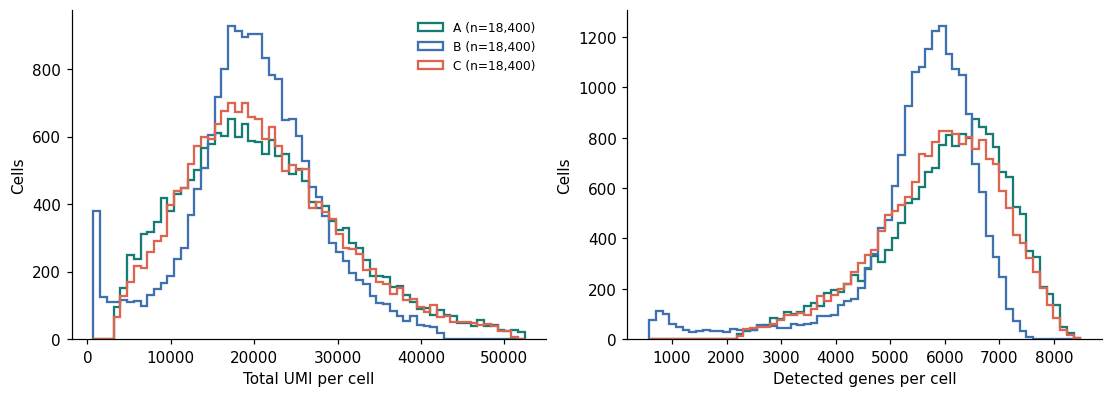

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
for ax, column, label in zip(axes, ['total_umi', 'detected_genes'],
                            ['Total UMI per cell', 'Detected genes per cell']):
    values = qc[column].to_numpy()
    bins = np.linspace(values.min(), values.max(), 65)
    for context in contexts:
        data = qc.loc[qc.context.eq(context), column]
        ax.hist(data, bins=bins, histtype='step', linewidth=1.5,
                color=COLORS[context], label=f'{context} (n={len(data):,})')
    ax.set(xlabel=label, ylabel='Cells')
axes[0].legend(fontsize=8)
show_figure(fig, 'control_qc_all_cells')

### 图 2：背景信息来自表达，不只来自 A/B/C 字符

**伪批量（pseudobulk）** 把一组细胞的计数汇总；这里每个点汇总一个 NTC guide 的 400 个细胞。先按总量归一化到 10,000，再 log1p，用 **PCA（principal component analysis，主成分分析）** 压缩成两个变化方向。

全部 138 个 guide 组、全部 18,533 个基因参与；每组细胞数相同。PCA 是描述性图，不是分类器或身份鉴定。由于没有随机化交换测量平台，背景分离也可能包含技术差异。

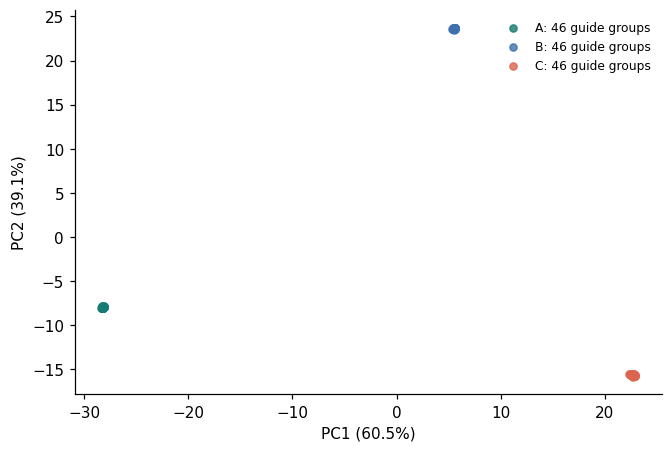

In [9]:
guide_counts = np.concatenate([scans[c][1] for c in contexts])
labels = [c for c in contexts for _ in scans[c][2]]
group_names = [g for c in contexts for g in scans[c][2]]
assert guide_counts.shape == (138, 18533)
depth = guide_counts.sum(axis=1, keepdims=True)
assert (depth > 0).all()
z = np.log1p(guide_counts / depth * 10000)
z -= z.mean(axis=0, keepdims=True)
# 138×138 Gram 矩阵即可求前两主成分，避免对大矩阵做完整 SVD。
eigvals, eigvecs = np.linalg.eigh(z @ z.T)
order = np.argsort(eigvals)[::-1]
eigvals = np.maximum(eigvals[order], 0)
scores = eigvecs[:, order[:2]] * np.sqrt(eigvals[:2])
explained = eigvals[:2] / eigvals.sum()
pca_table = pd.DataFrame({'context': labels, 'ntc_id': group_names,
                          'PC1': scores[:, 0], 'PC2': scores[:, 1]})
pca_table.to_csv(OUT / 'ntc_guide_pca.csv', index=False)
fig, ax = plt.subplots(figsize=(6, 4), layout='constrained')
for context in contexts:
    subset = pca_table.loc[pca_table.context.eq(context)]
    ax.scatter(subset.PC1, subset.PC2, s=22, alpha=0.8,
               color=COLORS[context], label=f'{context}: 46 guide groups')
ax.set(xlabel=f'PC1 ({explained[0]:.1%})', ylabel=f'PC2 ({explained[1]:.1%})')
ax.legend(fontsize=8)
show_figure(fig, 'ntc_guide_pca')

## 单元四：raw → CP10K → log1p，哪些信息会丢失

给每个细胞总计数记作 $L_i$。CP10K 是 `counts / L_i * 10000`，表示相对组成；log1p 是 `log(1 + value)`，压缩大值。

步骤必须是：先在声明的完整基因轴计算总量 → 做归一化 → 再取需要的基因。先挑 2,000 个基因再计算总量，会得到另一种尺度。下面只在内存小副本变换，不修改 H5AD 的原始 `.X`。

In [10]:
a = ad.read_h5ad(DATA / 'context_A.h5ad', backed='r')
try:
    raw = a.X[:8].tocsr().astype(np.float64)
finally:
    a.file.close()
library_sizes = np.asarray(raw.sum(axis=1)).ravel()
assert (library_sizes > 0).all()
cp10k = raw.multiply(10000 / library_sizes[:, None]).tocsr()
log_cp10k = cp10k.copy()
log_cp10k.data = np.log1p(log_cp10k.data)
assert np.allclose(np.asarray(cp10k.sum(axis=1)).ravel(), 10000)
col = genes.index('ADNP')
display(pd.DataFrame({'raw_ADNP': raw[:, col].toarray().ravel(),
                      'total_UMI': library_sizes,
                      'CP10K_ADNP': cp10k[:, col].toarray().ravel(),
                      'log1p_CP10K_ADNP': log_cp10k[:, col].toarray().ravel()}))
example = np.array([[1., 3.], [10., 30.]])  # 数学示例，不是实验数据
normalized = example / example.sum(axis=1, keepdims=True) * 10000
display(pd.DataFrame(normalized, columns=['gene_1_CP10K', 'gene_2_CP10K']))
print('两个不同总量的细胞归一化后相同；expm1 不能恢复原来的总量。')

,raw_ADNP,total_UMI,CP10K_ADNP,log1p_CP10K_ADNP
0,0.0,16080.0,0.000000,0.000000
1,4.0,26280.0,1.522070,0.925080
2,1.0,26603.0,0.375897,0.319106
3,0.0,8049.0,0.000000,0.000000
4,2.0,20817.0,0.960753,0.673329
5,2.0,31863.0,0.627687,0.487160
6,2.0,21623.0,0.924941,0.654895
7,1.0,18563.0,0.538706,0.430942


,gene_1_CP10K,gene_2_CP10K
0,2500.0,7500.0
1,2500.0,7500.0


两个不同总量的细胞归一化后相同；expm1 不能恢复原来的总量。


**诊断题：**只保存 `log1p(CP10K)`，以后用 `expm1` 再四舍五入，能否得到比赛要求的原始计数分布？

<details><summary>参考答案</summary>不能。expm1 只撤销 log1p，总计数归一化丢失的文库量仍需预测或采样；单细胞噪声和状态差异也需要保留。原始计数合格只是文件合同，不能保证生物分布正确。</details>

## 本课与微调方案的连接

你已经得到完整 A/B/C 数据合同和真实 NTC 特征。它们用于推理背景，**不提供监督微调标签**；训练需要公共 CRISPRi 对照与扰动细胞。下一课把这些矩阵变成 State 的集合输入。

- 下一份：[02｜State 模型、张量与迁移](02_state_model_and_transfer.ipynb)
- 官方：[About the Data](https://virtualcellchallenge.org/datasets)；[本地合同](../docs/Official-website/About-the-Data.md)
- 机制与来源：[数据基础课](../docs/lessons/01-数据合同与首个基线.md)、[论文索引](../docs/references/INDEX.md)

本课图表为完整本地数据的描述性分析，未推断隐匿细胞身份，也未获得扰动预测成绩。